In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mhealth_activity import Recording, Trace, Activity, WatchLocation, Path as MPath

%matplotlib widget

TRAIN_DIR = Path('data/train')
train_files = sorted(TRAIN_DIR.glob('*.pkl'))

# Dataset overview

In [22]:
# Load labels for all training recordings
def parse_activities(acts):
    # activities can be a dict {'standing': True, ...} or a list of int indices [0, 1, 2]
    if isinstance(acts, dict):
        return acts
    return {a.name.lower(): (a.value in acts) for a in Activity}

all_labels = []
for f in train_files:
    r = Recording(str(f))
    acts = parse_activities(r.labels['activities'])
    all_labels.append({
        'file': f.name,
        'path_idx': r.labels['path_idx'],
        'watch_loc': r.labels['watch_loc'],
        'step_count': r.labels['step_count'],
        'standing': acts['standing'],
        'walking': acts['walking'],
        'running': acts['running'],
        'cycling': acts['cycling'],
        'duration': r.data['ax'].total_time,
        'has_gps': 'latitude' in r.data,
    })

import pandas as pd
df = pd.DataFrame(all_labels)
print(f"Total recordings: {len(df)}")
print(f"With step count: {(df.step_count != -1).sum()}")
print(f"With GPS: {df.has_gps.sum()}")
df.head()

Total recordings: 396
With step count: 258
With GPS: 245


,file,path_idx,watch_loc,step_count,standing,walking,running,cycling,duration,has_gps
0,train_trace_000.pkl,0,0,-1.0,False,True,False,False,576.042,False
1,train_trace_001.pkl,1,1,NaN,True,True,False,False,788.925,True
2,train_trace_002.pkl,0,2,NaN,False,True,False,False,540.746,True
3,train_trace_003.pkl,2,0,NaN,False,True,False,False,733.139,True
4,train_trace_004.pkl,4,1,1023.0,False,True,False,False,530.442,True


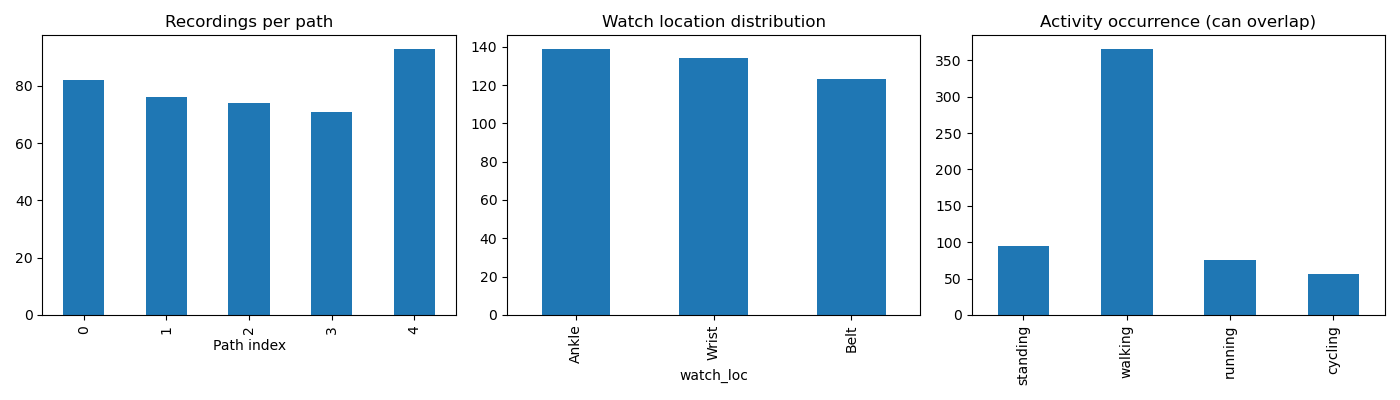

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Path distribution
df['path_idx'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Recordings per path')
axes[0].set_xlabel('Path index')

# Watch location distribution
loc_names = {0: 'Wrist', 1: 'Belt', 2: 'Ankle'}
df['watch_loc'].map(loc_names).value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Watch location distribution')

# Activity distribution
act_counts = df[['standing','walking','running','cycling']].sum()
act_counts.plot(kind='bar', ax=axes[2])
axes[2].set_title('Activity occurrence (can overlap)')

plt.tight_layout()
plt.show()

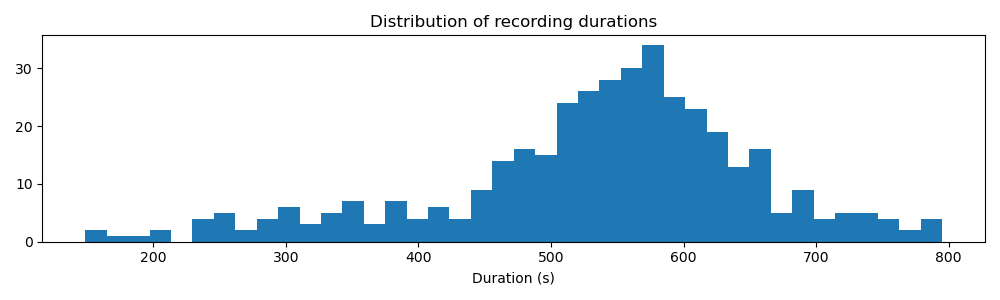

Min: 149s  Max: 795s  Mean: 535s


In [24]:
# Recording durations
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(df['duration'], bins=40)
ax.set_xlabel('Duration (s)')
ax.set_title('Distribution of recording durations')
plt.tight_layout()
plt.show()
print(f"Min: {df.duration.min():.0f}s  Max: {df.duration.max():.0f}s  Mean: {df.duration.mean():.0f}s")

# Single recording: raw signals

In [25]:
# Change this to explore different recordings
FILE = 'data/train/train_trace_013.pkl'
r = Recording(FILE)
print(r.labels)

{'path_idx': 2, 'watch_loc': 1, 'step_count': -1, 'activities': {'standing': False, 'walking': True, 'running': False, 'cycling': False}}


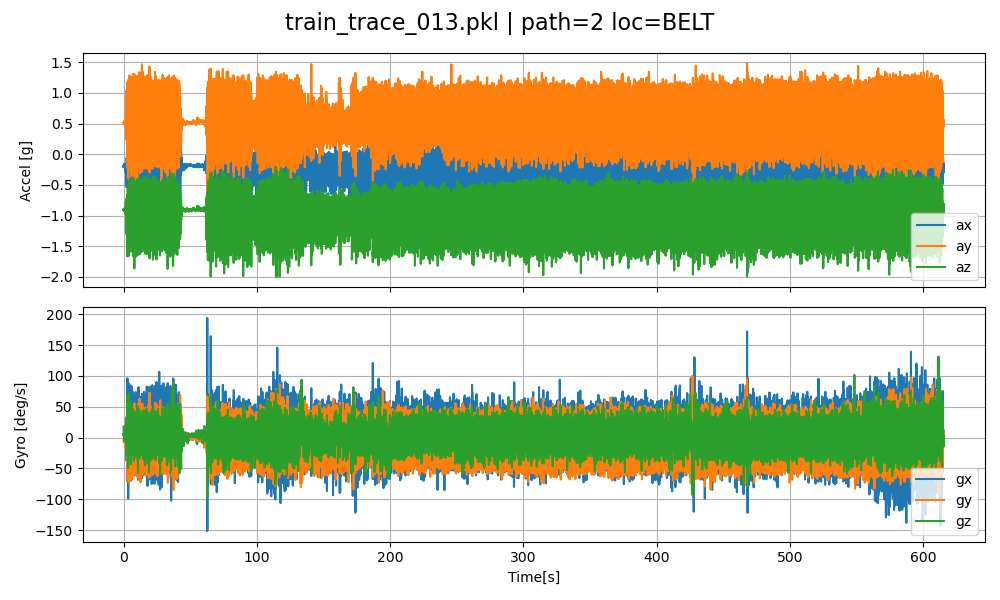

In [26]:
# Smartwatch IMU
r.plot(
    [['ax','ay','az'], ['gx','gy','gz']],
    ylabels=['Accel [g]', 'Gyro [deg/s]'],
    labels=[['ax','ay','az'],['gx','gy','gz']],
    title=f"{r.filename} | path={r.labels['path_idx']} loc={WatchLocation(r.labels['watch_loc']).name}"
)

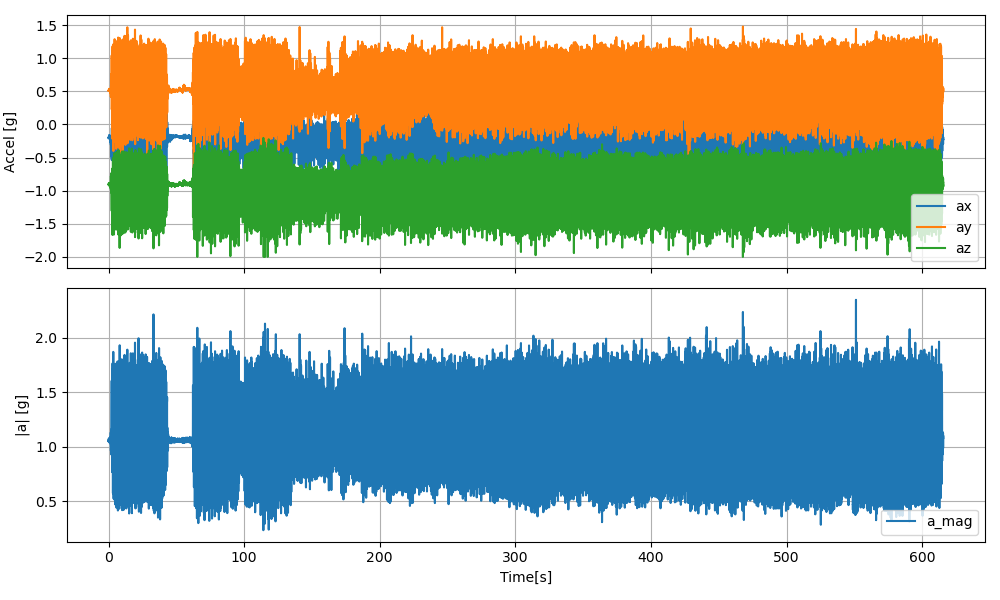

In [27]:
# Acceleration magnitude (useful for step counting)
ax_v = r.data['ax'].values
ay_v = r.data['ay'].values
az_v = r.data['az'].values
mag = np.sqrt(ax_v**2 + ay_v**2 + az_v**2)
r.data['a_mag'] = Trace.from_modified('a_mag', mag, r.data['ax'].timestamps, r.data['ax'].raw_timestamps[0][1])
r.plot([['ax','ay','az'], ['a_mag']], ylabels=['Accel [g]', '|a| [g]'])

# Compare same activity across watch locations

In [28]:
# Pick one walking recording per watch location
def pick_one(loc, activities=None):
    subset = df[df.watch_loc == loc]
    if activities:
        for act in activities:
            subset = subset[subset[act] == True]
    if subset.empty:
        return None
    return subset.iloc[0]['file']

files_by_loc = {loc: pick_one(loc, ['walking']) for loc in [0,1,2]}
print(files_by_loc)

{0: 'train_trace_000.pkl', 1: 'train_trace_001.pkl', 2: 'train_trace_002.pkl'}


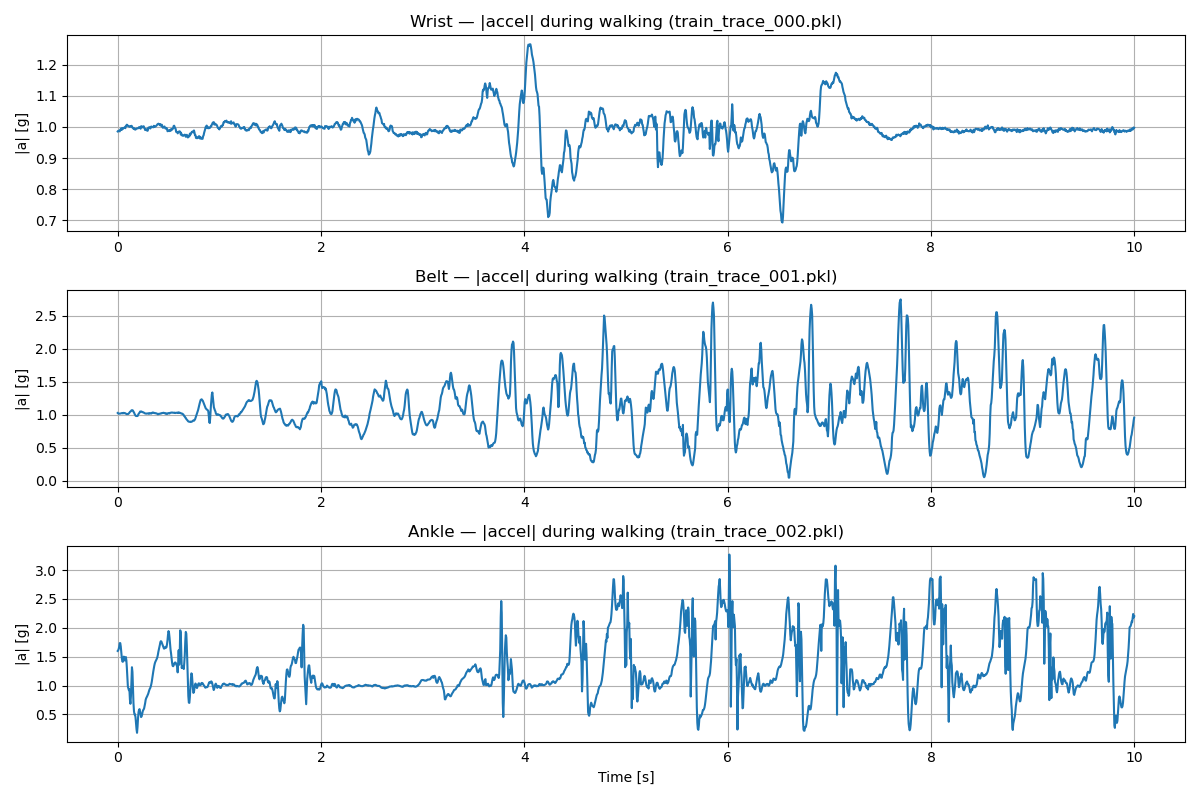

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
loc_names = {0: 'Wrist', 1: 'Belt', 2: 'Ankle'}
WINDOW = 10  # seconds to show

for i, (loc, fname) in enumerate(files_by_loc.items()):
    if fname is None:
        continue
    rec = Recording(str(TRAIN_DIR / fname))
    ax_v = rec.data['ax'].values
    ay_v = rec.data['ay'].values
    az_v = rec.data['az'].values
    mag = np.sqrt(ax_v**2 + ay_v**2 + az_v**2)
    ts = rec.data['ax'].timestamps
    mask = ts < WINDOW
    axes[i].plot(ts[mask], mag[mask])
    axes[i].set_title(f'{loc_names[loc]} — |accel| during walking ({fname})')
    axes[i].set_ylabel('|a| [g]')
    axes[i].grid(True)

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

# Frequency spectrum per watch location

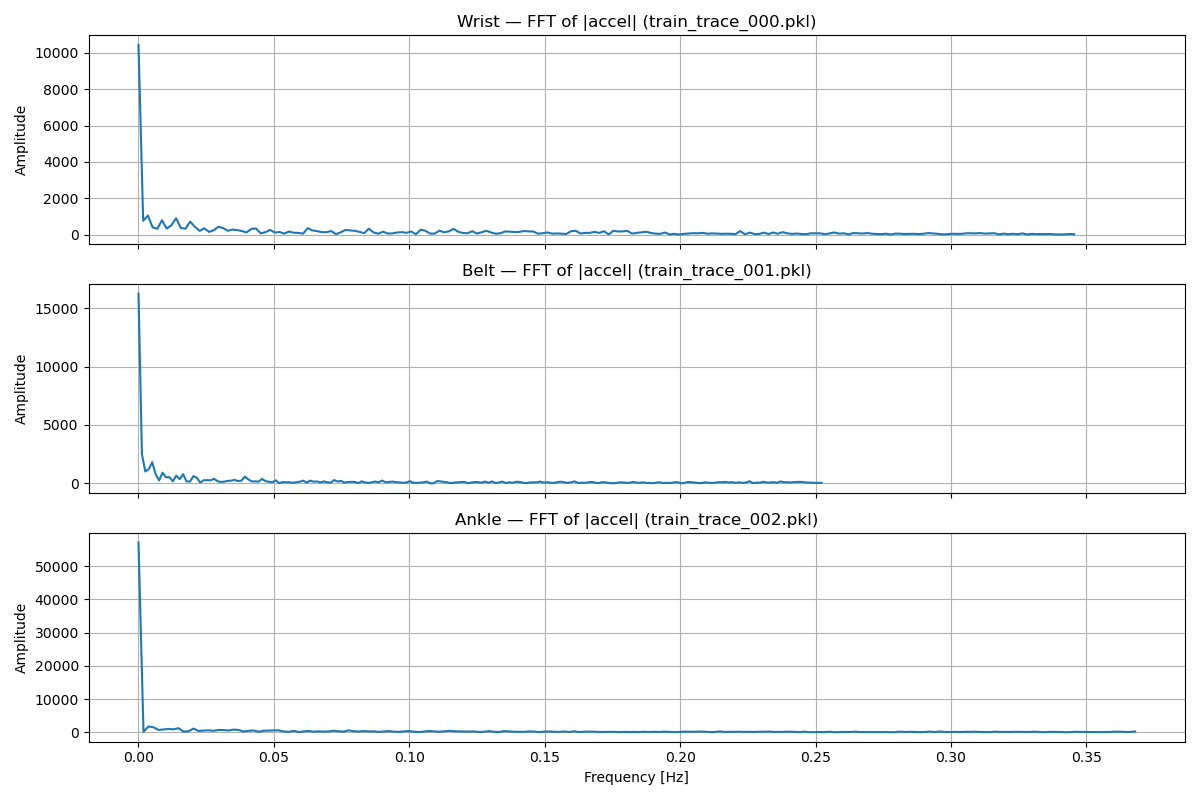

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, (loc, fname) in enumerate(files_by_loc.items()):
    if fname is None:
        continue
    rec = Recording(str(TRAIN_DIR / fname))
    ax_v = rec.data['ax'].values
    ay_v = rec.data['ay'].values
    az_v = rec.data['az'].values
    mag = np.sqrt(ax_v**2 + ay_v**2 + az_v**2) - 1.0  # remove gravity
    fs = rec.data['ax'].samplerate
    freqs = np.fft.rfftfreq(len(mag), d=1/fs)
    spectrum = np.abs(np.fft.rfft(mag))
    axes[i].plot(freqs[:200], spectrum[:200])
    axes[i].set_title(f'{loc_names[loc]} — FFT of |accel| ({fname})')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True)

axes[-1].set_xlabel('Frequency [Hz]')
plt.tight_layout()
plt.show()

# Compare activities: walking vs running vs cycling vs standing

In [31]:
# Find pure recordings (only one activity) - or best available
activity_examples = {}
for act in ['walking', 'running', 'cycling', 'standing']:
    subset = df[df[act] == True]
    # prefer pure recordings
    others = [a for a in ['walking','running','cycling','standing'] if a != act]
    pure = subset.copy()
    for o in others:
        pure = pure[pure[o] == False]
    activity_examples[act] = pure.iloc[0]['file'] if not pure.empty else subset.iloc[0]['file']
    print(f"{act}: {activity_examples[act]} (pure={not pure.empty})")

walking: train_trace_000.pkl (pure=True)
running: train_trace_015.pkl (pure=True)
cycling: train_trace_006.pkl (pure=True)
standing: train_trace_001.pkl (pure=False)


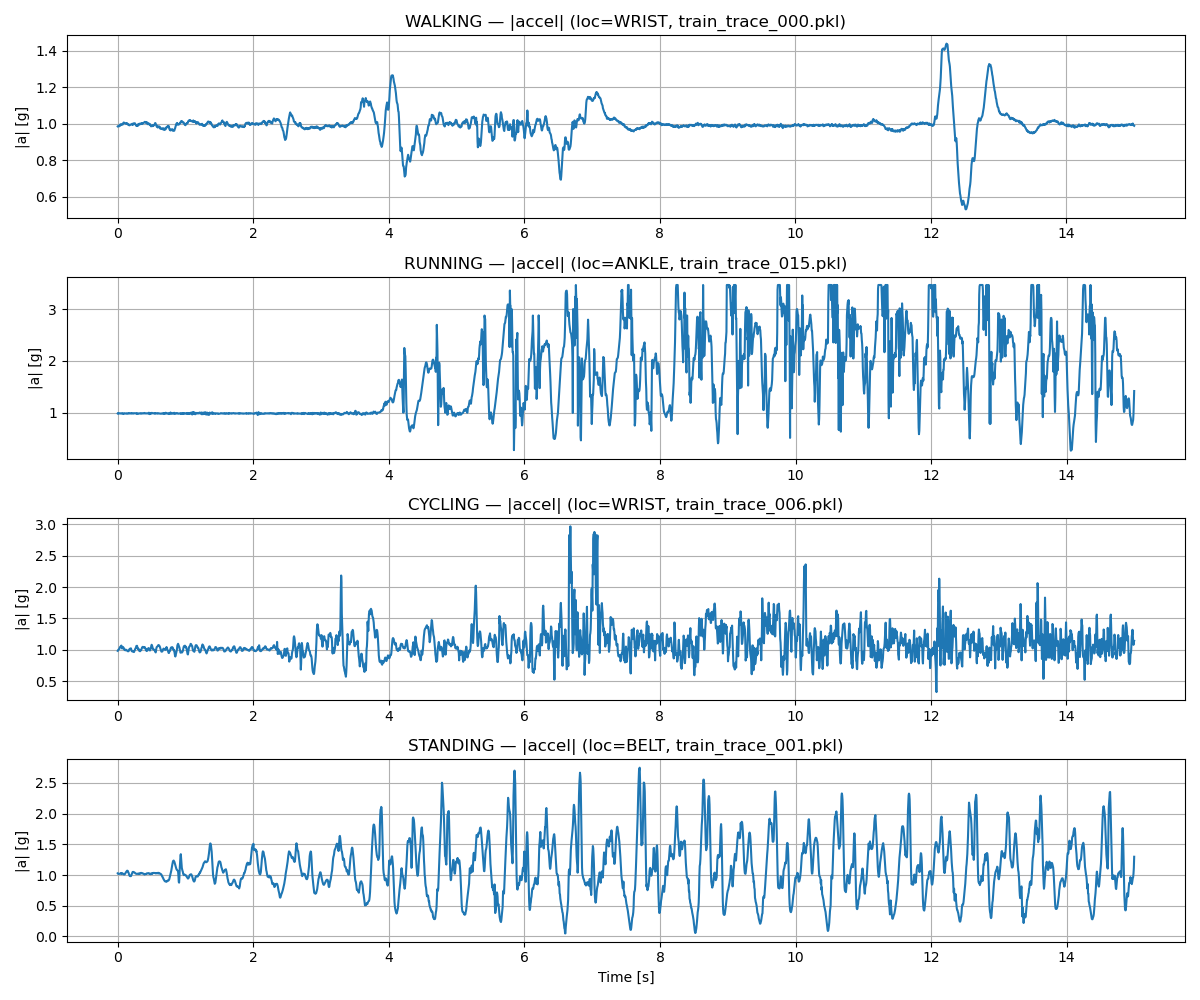

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=False)
WINDOW = 15

for i, (act, fname) in enumerate(activity_examples.items()):
    rec = Recording(str(TRAIN_DIR / fname))
    ax_v = rec.data['ax'].values
    ay_v = rec.data['ay'].values
    az_v = rec.data['az'].values
    mag = np.sqrt(ax_v**2 + ay_v**2 + az_v**2)
    ts = rec.data['ax'].timestamps
    mask = ts < WINDOW
    loc = WatchLocation(rec.labels['watch_loc']).name
    axes[i].plot(ts[mask], mag[mask])
    axes[i].set_title(f'{act.upper()} — |accel| (loc={loc}, {fname})')
    axes[i].set_ylabel('|a| [g]')
    axes[i].grid(True)

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

# GPS paths on map

In [ ]:
import matplotlib.image as mpimg

BBOX = (8.5373, 8.5593, 47.3673, 47.3880)
map_img = mpimg.imread('mapzurich.png')
colors = ['red', 'blue', 'green', 'orange', 'purple']

gps_df = df[df.has_gps]

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(map_img, extent=BBOX, zorder=0)

for path_idx in range(5):
    subset = gps_df[gps_df.path_idx == path_idx]
    if subset.empty:
        continue
    fname = subset.iloc[0]['file']
    rec = Recording(str(TRAIN_DIR / fname))
    lons = rec.data['longitude'].values
    lats = rec.data['latitude'].values
    ax.scatter(lons, lats, s=5, color=colors[path_idx], label=f'Path {path_idx}', zorder=1)

ax.set_xlim(BBOX[0], BBOX[1])
ax.set_ylim(BBOX[2], BBOX[3])
ax.legend()
ax.set_title('GPS traces by path index')
plt.tight_layout()
plt.show()

# Barometric pressure (altitude proxy) per path

Recordings with pressure (out of first 50): 42


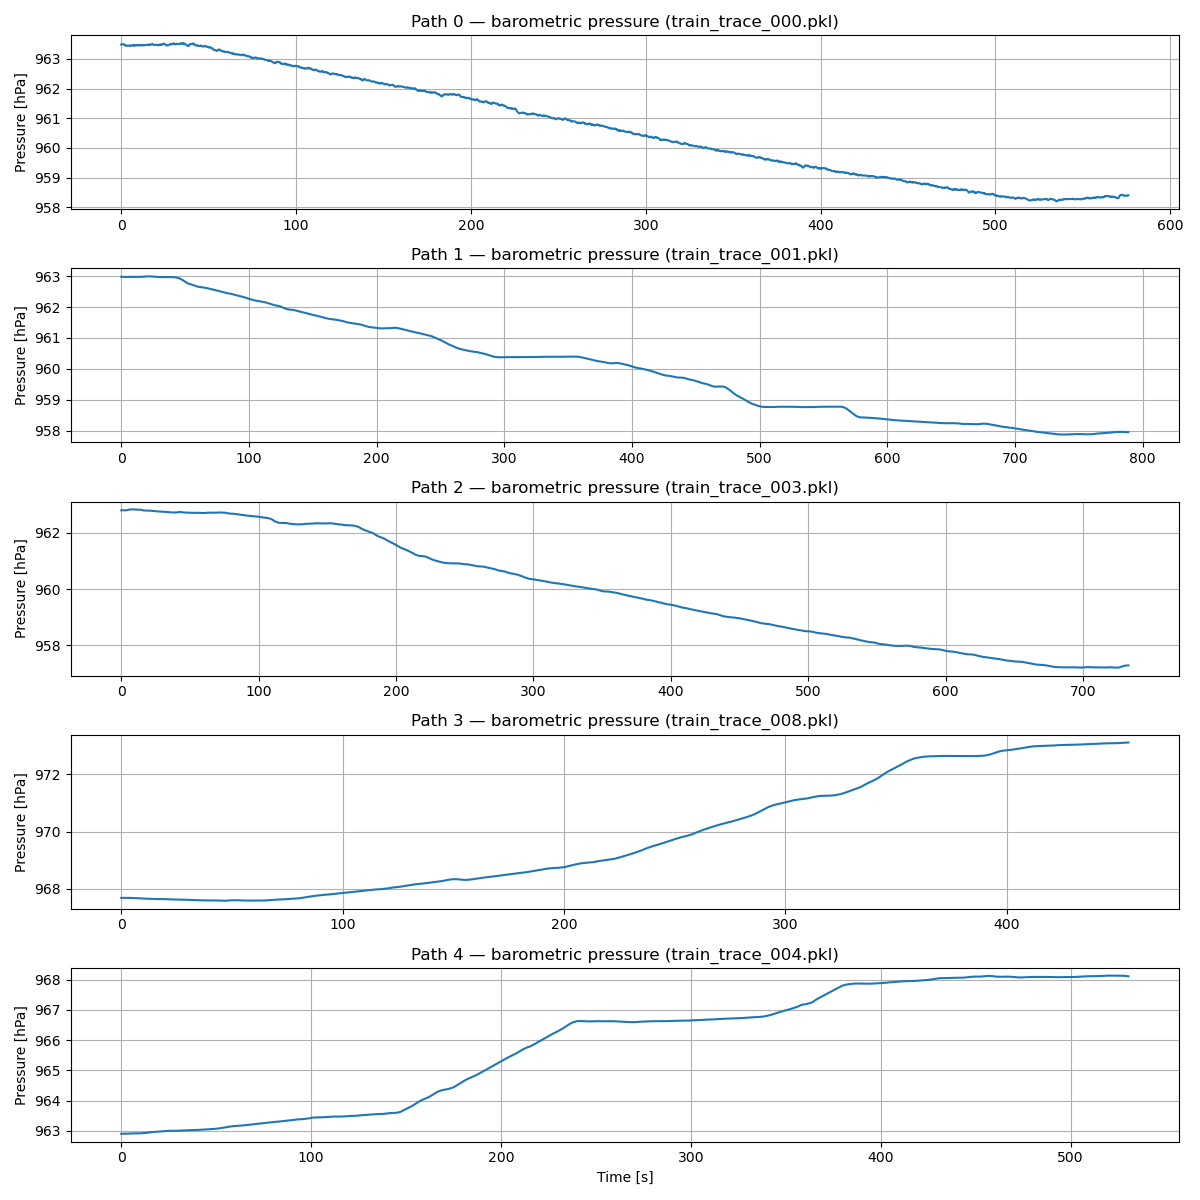

In [34]:
# Check which recordings have pressure data
has_pressure = []
for f in train_files[:50]:  # sample first 50 to be fast
    r = Recording(str(f))
    if 'phone_pressure' in r.data:
        has_pressure.append((f.name, r.labels['path_idx'], r))

print(f"Recordings with pressure (out of first 50): {len(has_pressure)}")

# Plot pressure trace per path
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=False)
path_seen = set()

for fname, path_idx, rec in has_pressure:
    if path_idx in path_seen:
        continue
    path_seen.add(path_idx)
    p = rec.data['phone_pressure']
    axes[path_idx].plot(p.timestamps, p.values)
    axes[path_idx].set_title(f'Path {path_idx} — barometric pressure ({fname})')
    axes[path_idx].set_ylabel('Pressure [hPa]')
    axes[path_idx].grid(True)
    if len(path_seen) == 5:
        break

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

# All GPS traces overlaid per path

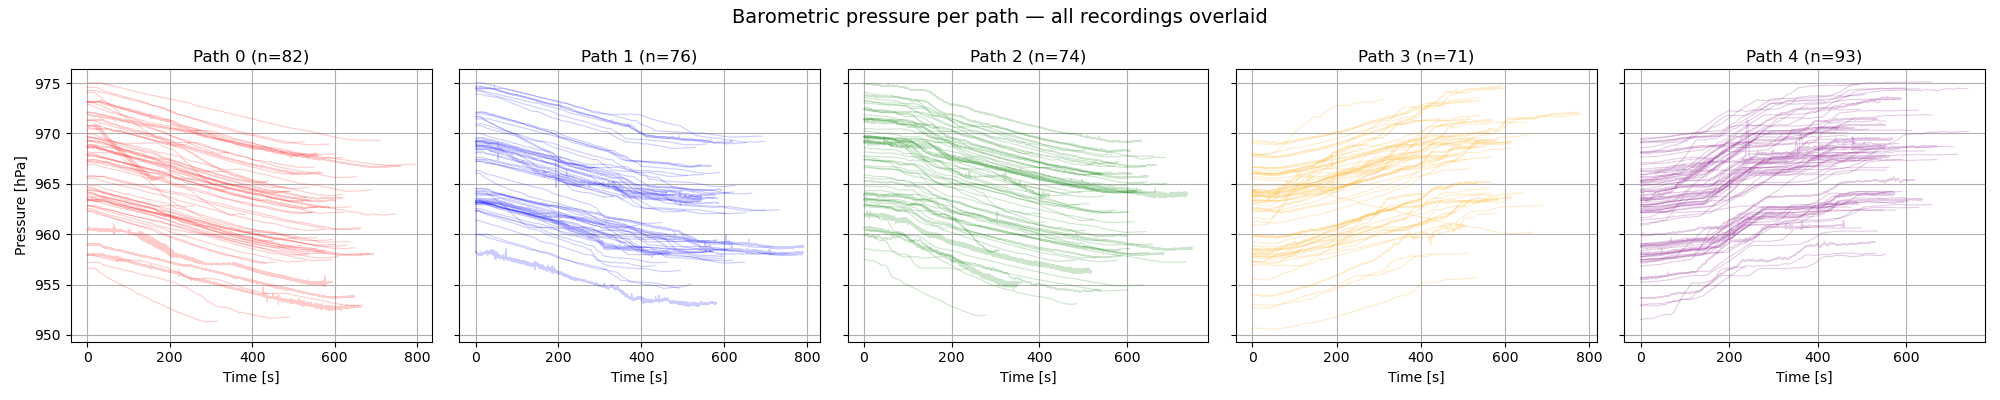

: 

In [ ]:
colors = ['red', 'blue', 'green', 'orange', 'purple']

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for path_idx in range(5):
    ax = axes[path_idx]
    subset = df[df.path_idx == path_idx]
    for _, row in subset.iterrows():
        rec = Recording(str(TRAIN_DIR / row['file']))
        if 'phone_pressure' not in rec.data:
            continue
        p = rec.data['phone_pressure']
        ax.plot(p.timestamps, p.values, color=colors[path_idx], alpha=0.2, linewidth=0.8)
    ax.set_title(f'Path {path_idx} (n={len(subset)})')
    ax.set_xlabel('Time [s]')
    ax.grid(True)

axes[0].set_ylabel('Pressure [hPa]')
plt.suptitle('Barometric pressure per path — all recordings overlaid', fontsize=14)
plt.tight_layout()
plt.show()